In [28]:
import pandas as pd

In [29]:
data = pd.read_csv('Dataset .csv')

In [30]:
print(data.head())

   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo, Legaspi Village, Makati City   
2  Edsa Shangri-La, Ortigas, Mandaluyong City   
3      SM 

In [31]:
print(data.shape)

(9551, 21)


In [32]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [33]:
print(data.describe())

       Restaurant ID  Country Code    Longitude     Latitude  \
count   9.551000e+03   9551.000000  9551.000000  9551.000000   
mean    9.051128e+06     18.365616    64.126574    25.854381   
std     8.791521e+06     56.750546    41.467058    11.007935   
min     5.300000e+01      1.000000  -157.948486   -41.330428   
25%     3.019625e+05      1.000000    77.081343    28.478713   
50%     6.004089e+06      1.000000    77.191964    28.570469   
75%     1.835229e+07      1.000000    77.282006    28.642758   
max     1.850065e+07    216.000000   174.832089    55.976980   

       Average Cost for two  Price range  Aggregate rating         Votes  
count           9551.000000  9551.000000       9551.000000   9551.000000  
mean            1199.210763     1.804837          2.666370    156.909748  
std            16121.183073     0.905609          1.516378    430.169145  
min                0.000000     1.000000          0.000000      0.000000  
25%              250.000000     1.000000        

## Data Visualization

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

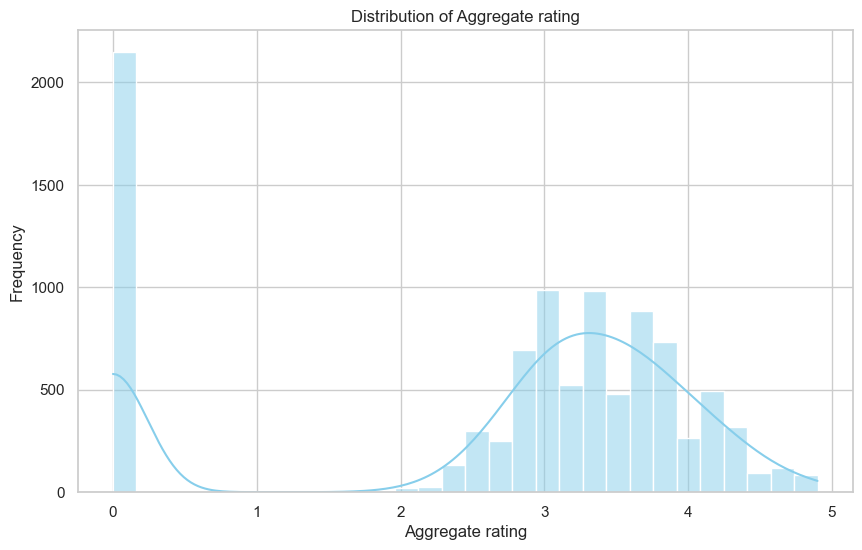

In [35]:
# Visualizing the distribution of Aggregate rating
plt.figure(figsize=(10, 6))
sns.histplot(data['Aggregate rating'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Aggregate rating')
plt.xlabel('Aggregate rating')
plt.ylabel('Frequency')
plt.show()

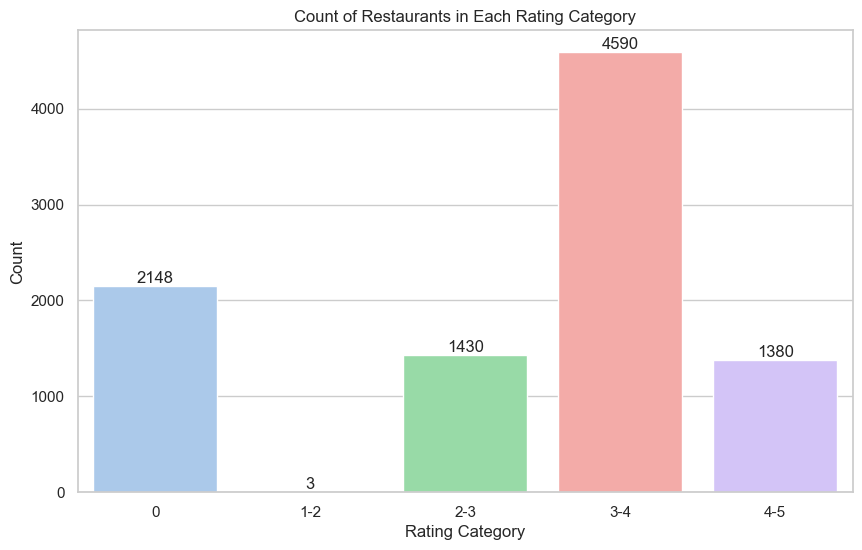

In [36]:
bins = [0, 1, 2, 3, 4, 5]
labels = ['0', '1-2', '2-3', '3-4', '4-5']

rating_category = pd.cut(data['Aggregate rating'], bins=bins, labels=labels, right=False)

rating_counts = rating_category.value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, palette='pastel', legend=False)

for i, count in enumerate(rating_counts.values):
    plt.text(i, count + 0.2, str(count), ha='center', va='bottom')

plt.title('Count of Restaurants in Each Rating Category')
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.show()

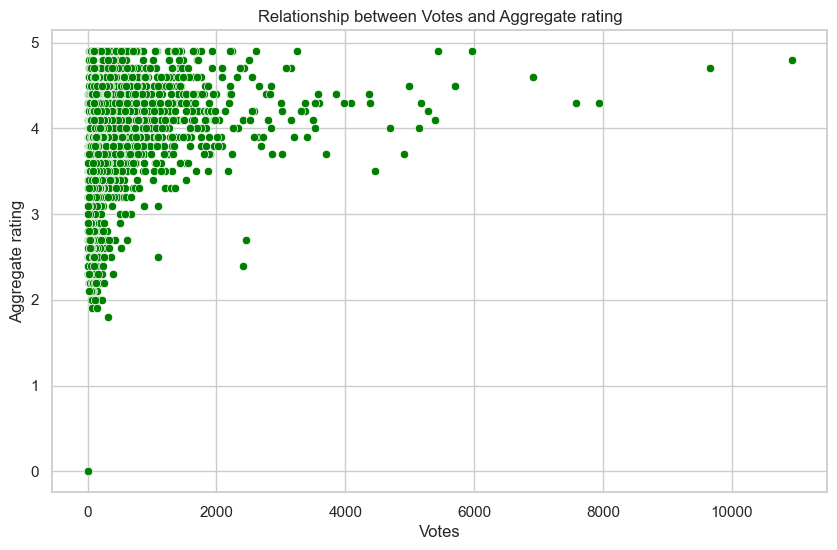

In [37]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Votes', y='Aggregate rating', data=data, color='green')
plt.title('Relationship between Votes and Aggregate rating')
plt.xlabel('Votes')
plt.ylabel('Aggregate rating')
plt.show()

In [38]:
unique_price_range = data['Price range'].unique()
print("Unique values of Price range column:", unique_price_range)

Unique values of Price range column: [3 4 2 1]


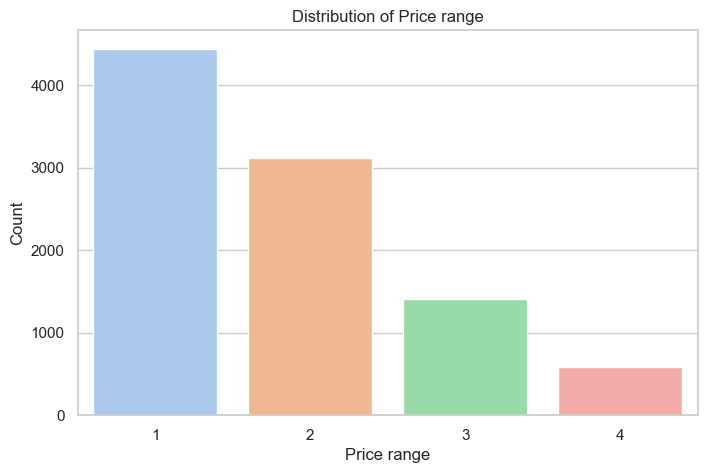

In [39]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Price range', data=data, hue='Price range', palette='pastel', legend=False)
plt.title('Distribution of Price range')
plt.xlabel('Price range')
plt.ylabel('Count')
plt.show()

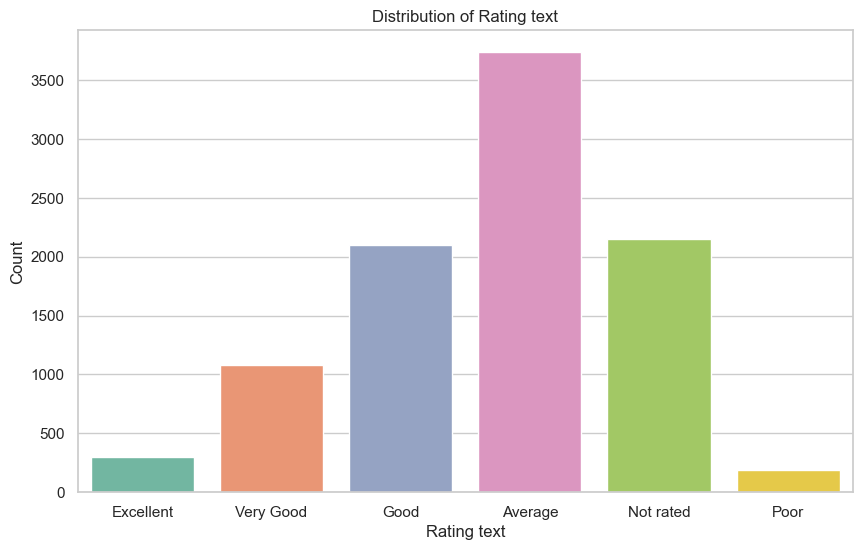

In [40]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Rating text', data=data, hue='Rating text', palette='Set2', legend=False)
plt.title('Distribution of Rating text')
plt.xlabel('Rating text')
plt.ylabel('Count')
plt.show()

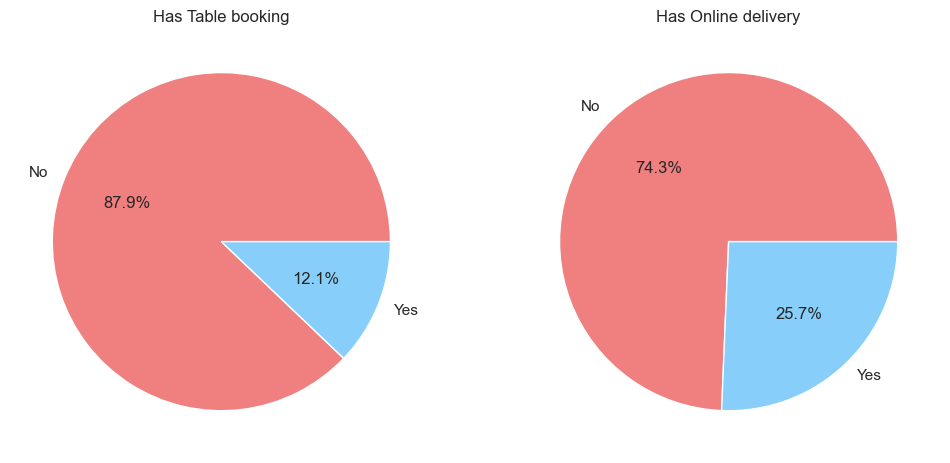

In [41]:
table_booking_counts = data['Has Table booking'].value_counts()
online_delivery_counts = data['Has Online delivery'].value_counts()

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.pie(table_booking_counts, labels=table_booking_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title('Has Table booking')

plt.subplot(1, 2, 2)
plt.pie(online_delivery_counts, labels=online_delivery_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title('Has Online delivery')

plt.show()

## Data Pre-processing

In [42]:
print(data.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [43]:
data.dropna(subset=['Cuisines'], inplace=True)

In [44]:
print(data.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [45]:
data.shape

(9542, 21)

In [46]:
for col in data.columns:
    print(f"Unique values for column '{col}':", len(data[col].unique()))

Unique values for column 'Restaurant ID': 9542
Unique values for column 'Restaurant Name': 7437
Unique values for column 'Country Code': 15
Unique values for column 'City': 140
Unique values for column 'Address': 8910
Unique values for column 'Locality': 1206
Unique values for column 'Locality Verbose': 1263
Unique values for column 'Longitude': 8111
Unique values for column 'Latitude': 8668
Unique values for column 'Cuisines': 1825
Unique values for column 'Average Cost for two': 140
Unique values for column 'Currency': 12
Unique values for column 'Has Table booking': 2
Unique values for column 'Has Online delivery': 2
Unique values for column 'Is delivering now': 2
Unique values for column 'Switch to order menu': 1
Unique values for column 'Price range': 4
Unique values for column 'Aggregate rating': 33
Unique values for column 'Rating color': 6
Unique values for column 'Rating text': 6
Unique values for column 'Votes': 1012


In [47]:
# Required columns/features for recommendation system
required_columns = ['Restaurant ID','Restaurant Name', 'City','Address', 'Cuisines', 'Has Table booking', 'Has Online delivery', 
                    'Price range', 'Aggregate rating']

# Create a new DataFrame with only the required columns
df = data[required_columns].copy()

df

,Restaurant ID,Restaurant Name,City,Address,Cuisines,Has Table booking,Has Online delivery,Price range,Aggregate rating
0,6317637,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","French, Japanese, Desserts",Yes,No,3,4.8
1,6304287,Izakaya Kikufuji,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",Japanese,Yes,No,3,4.5
2,6300002,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Seafood, Asian, Filipino, Indian",Yes,No,4,4.4
3,6318506,Ooma,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","Japanese, Sushi",No,No,4,4.9
4,6314302,Sambo Kojin,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","Japanese, Korean",Yes,No,4,4.8
...,...,...,...,...,...,...,...,...,...
9546,5915730,Naml۱ Gurme,��stanbul,"Kemanke�� Karamustafa Pa��a Mahallesi, R۱ht۱m ...",Turkish,No,No,3,4.1
9547,5908749,Ceviz A��ac۱,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...","World Cuisine, Patisserie, Cafe",No,No,3,4.2
9548,5915807,Huqqa,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...","Italian, World Cuisine",No,No,4,3.7
9549,5916112,A���k Kahve,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Restaurant Cafe,No,No,4,4.0


In [48]:
# Splitting cuisines and duplicating rows
df = df.assign(Cuisines=df['Cuisines'].str.split(', ')).explode('Cuisines').reset_index(drop=True)
df

,Restaurant ID,Restaurant Name,City,Address,Cuisines,Has Table booking,Has Online delivery,Price range,Aggregate rating
0,6317637,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...",French,Yes,No,3,4.8
1,6317637,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...",Japanese,Yes,No,3,4.8
2,6317637,Le Petit Souffle,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...",Desserts,Yes,No,3,4.8
3,6304287,Izakaya Kikufuji,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",Japanese,Yes,No,3,4.5
4,6300002,Heat - Edsa Shangri-La,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",Seafood,Yes,No,4,4.4
...,...,...,...,...,...,...,...,...,...
19705,5908749,Ceviz A��ac۱,��stanbul,"Ko��uyolu Mahallesi, Muhittin ��st�_nda�� Cadd...",Cafe,No,No,3,4.2
19706,5915807,Huqqa,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Italian,No,No,4,3.7
19707,5915807,Huqqa,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",World Cuisine,No,No,4,3.7
19708,5916112,A���k Kahve,��stanbul,"Kuru�_e��me Mahallesi, Muallim Naci Caddesi, N...",Restaurant Cafe,No,No,4,4.0


## Recommendation based on City selection sorted by Rating

In [49]:
def get_restaurants_by_city(city):
    city_restaurants = df[df['City'] == city]
    
    if city_restaurants.empty:
        return "No restaurants found in the provided city."
    restaurant_details = {}
    
    for index, row in city_restaurants.iterrows():
        restaurant_name = row['Restaurant Name']
        if restaurant_name in restaurant_details:
            restaurant_details[restaurant_name]['Cuisines'].append(row['Cuisines'])
        else:
            restaurant_details[restaurant_name] = {
                'City': row['City'],
                'Cuisines': [row['Cuisines']],
                'Has Table Booking': row['Has Table booking'],
                'Has Online Delivery': row['Has Online delivery'],
                'Price Range': row['Price range'],
                'Aggregate Rating': row['Aggregate rating'],
                'Address': row['Address']
            }
    
    sorted_restaurant_details = sorted(restaurant_details.items(), key=lambda x: x[1]['Aggregate Rating'], reverse=True)
    output = ""
    for restaurant_name, details in sorted_restaurant_details:
        cuisines = ', '.join(details['Cuisines'])
        restaurant_info = f"Restaurant Name: {restaurant_name}\n" \
                          f"City: {details['City']}\n" \
                          f"Cuisines: {cuisines}\n" \
                          f"Has Table Booking: {details['Has Table Booking']}\n" \
                          f"Has Online Delivery: {details['Has Online Delivery']}\n" \
                          f"Price Range: {details['Price Range']}\n" \
                          f"Aggregate Rating: {details['Aggregate Rating']}\n" \
                          f"Address: {details['Address']}\n\n"
        output += restaurant_info
    return output

city = input("Enter the city: ")
print()
print(get_restaurants_by_city(city))


No restaurants found in the provided city.


## Restsaurent Recommendation based on Cuisine and City selection sorted by Rating

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def print_restaurant_details(restaurant):
    print("Restaurant Name:", restaurant['Restaurant Name'])
    print("City:", restaurant['City'])
    print("Cuisines:", restaurant['Cuisines'])
    print("Has Table Booking:", restaurant['Has Table booking'])
    print("Has Online Delivery:", restaurant['Has Online delivery'])
    print("Price Range:", restaurant['Price range'])
    print("Aggregate Rating:", restaurant['Aggregate rating'])
    print("Address:", restaurant['Address'])
    print("\n")

def get_cuisine_city_recommendations(cuisine, city, cosine_sim):
    cuisine_restaurants = df[(df['Cuisines'].str.contains(cuisine, case=False)) & (df['City'] == city)]
    if cuisine_restaurants.empty:
        return "No restaurants found for the provided cuisine and city."
    random_restaurant = cuisine_restaurants.sample()
    idx = random_restaurant.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    restaurant_indices = [i[0] for i in sim_scores]
    similar_restaurants = df.iloc[restaurant_indices]
    similar_restaurants_sorted = similar_restaurants.sort_values(by='Aggregate rating', ascending=False)
    for index, restaurant in similar_restaurants_sorted.iterrows():
        print_restaurant_details(restaurant)

cuisine = input("Enter the cuisine: ")
city = input("Enter the city: ")

count_vectorizer = CountVectorizer(stop_words='english')
cuisine_matrix = count_vectorizer.fit_transform(df['Cuisines'])
cosine_sim = cosine_similarity(cuisine_matrix, cuisine_matrix)
get_cuisine_city_recommendations(cuisine, city, cosine_sim)

'No restaurants found for the provided cuisine and city.'

## Recommendation based on Restaurant

In [51]:
def get_restaurant_details_by_name(restaurant_name, df):
    restaurant = df[df['Restaurant Name'] == restaurant_name]
    if restaurant.empty:
        return "No restaurant found with the provided name."
    restaurant_details = ""
    restaurant_details += "Restaurant Name: {}\n".format(restaurant['Restaurant Name'].values[0])
    restaurant_details += "City: {}\n".format(restaurant['City'].values[0])
    restaurant_details += "Cuisines: {}\n".format(restaurant['Cuisines'].values)
    restaurant_details += "Has Table Booking: {}\n".format(restaurant['Has Table booking'].values[0])
    restaurant_details += "Has Online Delivery: {}\n".format(restaurant['Has Online delivery'].values[0])
    restaurant_details += "Price Range: {}\n".format(restaurant['Price range'].values[0])
    restaurant_details += "Aggregate Rating: {}\n".format(restaurant['Aggregate rating'].values[0])
    restaurant_details += "Address: {}\n".format(restaurant['Address'].values[0])
    return restaurant_details

rest=input("Enter Restaurent Name: ")
restaurant_details = get_restaurant_details_by_name(rest, df)
print(restaurant_details)

No restaurant found with the provided name.


## Recommendation based on Price Range & Rating

In [53]:
def get_recommendations(price_range, aggregate_rating, df):
    filtered_restaurants = df[(df['Price range'] == price_range) & (df['Aggregate rating'] >= aggregate_rating)]
    if filtered_restaurants.empty:
        return "No restaurants found matching the provided criteria."
    sorted_restaurants = filtered_restaurants.sort_values(by='Aggregate rating', ascending=False)
    top_10_restaurants = sorted_restaurants.head(10)
    output = ""
    for index, restaurant in top_10_restaurants.iterrows():
        output += f"Restaurant Name: {restaurant['Restaurant Name']}\n"
        output += f"City: {restaurant['City']}\n"
        output += f"Cuisines: {restaurant['Cuisines']}\n"
        output += f"Has Table Booking: {restaurant['Has Table booking']}\n"
        output += f"Has Online Delivery: {restaurant['Has Online delivery']}\n"
        output += f"Price Range: {restaurant['Price range']}\n"
        output += f"Aggregate Rating: {restaurant['Aggregate rating']}\n"
        output += f"Address: {restaurant['Address']}\n"
        output += "\n"
    return output

price_range = int(input("Enter the price range(1-4): "))
aggregate_rating = float(input("Enter the minimum aggregate rating(0-4.9): "))
print()

recommendations = get_recommendations(price_range, aggregate_rating, df)
print(recommendations)


No restaurants found matching the provided criteria.


## Recommendation based on City, Online Delivery option Sorted by Rating

In [ ]:
def get_recommendations_by_criteria(city, has_online_delivery, df):
    filtered_restaurants = df[(df['City'] == city) & (df['Has Online delivery'] == has_online_delivery)]
    
    if filtered_restaurants.empty:
        return "No restaurants found matching the provided criteria."
    sorted_restaurants = filtered_restaurants.sort_values(by='Aggregate rating', ascending=False)
    top_10_restaurants = sorted_restaurants.head(10)
    output = ""
    
    for index, restaurant in top_10_restaurants.iterrows():
        output += f"Restaurant Name: {restaurant['Restaurant Name']}\n"
        output += f"City: {restaurant['City']}\n"
        output += f"Cuisines: {restaurant['Cuisines']}\n"
        output += f"Has Table Booking: {restaurant['Has Table booking']}\n"
        output += f"Has Online Delivery: {restaurant['Has Online delivery']}\n"
        output += f"Price Range: {restaurant['Price range']}\n"
        output += f"Aggregate Rating: {restaurant['Aggregate rating']}\n"
        output += f"Address: {restaurant['Address']}\n"
        output += "\n"
    return output

city = input("Enter the city: ")
has_online_delivery = input("Does the restaurant offer online delivery? (Yes/No): ")
print()
recommendations = get_recommendations_by_criteria(city, has_online_delivery, df)
print(recommendations)


No restaurants found matching the provided criteria.
